In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df =pd.read_csv('C:/Users/Lenovo/Downloads/college_sleep_and_gpa.csv')

In [4]:
df.head()

,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54


In [75]:
df.describe()

,student_id,study,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep
count,634.000000,634.000000,630.000000,633.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,487.000000,487.000000,634.000000
mean,13005.892744,3.181388,0.166667,0.187994,397.324763,6.622098,41.165615,398.678707,0.451687,0.867478,3.465584,3.449587,-0.015997,29.392197,-0.000057,0.208202
std,26496.593477,1.317125,0.377213,0.391016,50.855641,0.847741,27.388294,72.712017,1.393631,0.178999,0.437578,0.500463,0.403109,17.642780,1.000017,0.406343
min,1.000000,1.000000,0.000000,0.000000,194.800000,3.250000,2.300000,247.100000,0.004500,0.214000,1.210000,0.350000,-1.877000,5.000000,-3.983000,0.000000
25%,178.000000,2.000000,0.000000,0.000000,366.950000,6.112500,23.100000,345.175000,0.074700,0.821000,3.232250,3.233000,-0.189500,15.000000,-0.551000,0.000000
50%,358.500000,3.000000,0.000000,0.000000,400.350000,6.675000,35.000000,388.250000,0.135000,0.932000,3.558000,3.556000,0.000000,17.000000,0.041000,0.000000
75%,592.750000,4.000000,0.000000,0.000000,430.100000,7.170000,51.250000,437.625000,0.291700,1.000000,3.789500,3.810000,0.193750,48.000000,0.560000,0.000000
max,99978.000000,5.000000,2.000000,1.000000,587.700000,9.790000,292.300000,724.700000,20.849200,1.000000,4.000000,4.000000,1.332000,73.000000,4.055000,1.000000


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               634 non-null    int64  
 1   study                    634 non-null    int64  
 2   university               634 non-null    str    
 3   semester                 634 non-null    str    
 4   cohort_code              634 non-null    str    
 5   gender                   631 non-null    str    
 6   first_generation         630 non-null    float64
 7   underrepresented         633 non-null    float64
 8   avg_sleep_minutes        634 non-null    float64
 9   avg_sleep_hours          634 non-null    float64
 10  daytime_sleep_minutes    634 non-null    float64
 11  sleep_midpoint_minutes   634 non-null    float64
 12  bedtime_variability      634 non-null    float64
 13  nights_tracked_fraction  634 non-null    float64
 14  prior_gpa                634 non-null

Text(0.5, 1.0, 'sleep bracket distribution')

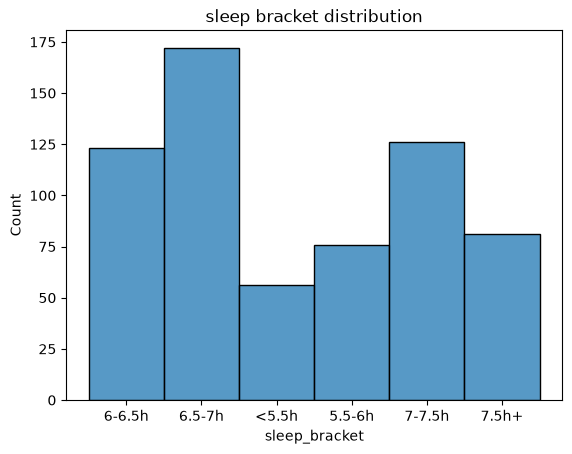

In [ ]:
sns.histplot(x='sleep_bracket',data=df)
plt.title('sleep bracket distribution')

By seeing the describtion and the info of the data ,decided i will use regression to predict the term_gpa by training the other features, first we have to do preprocessing and fill or drop the null values, then encoding and scaling 

In [11]:
df['first_generation']=df['first_generation'].fillna(df['first_generation'].mode()[0])
df['term_units']=df['term_units'].fillna(df['term_units'].mean())
df['term_load_z']=df['term_load_z'].fillna(df['term_load_z'].mean())
df=df.drop(['sleep_midpoint_clock'],axis=1)
df=df.dropna()

In [12]:
X = df.drop(['term_gpa', 'gpa_change', 'student_id'], axis=1)
y=df['term_gpa']

In [13]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test =train_test_split(X, y, test_size=0.2, random_state=20)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=20 )

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(handle_unknown='ignore')
scalar = StandardScaler()

preprocessor = ColumnTransformer([
    ('num', scalar, [ 'study','first_generation', 'underrepresented', 'avg_sleep_minutes',
       'avg_sleep_hours', 'daytime_sleep_minutes', 'sleep_midpoint_minutes',
       'bedtime_variability', 'nights_tracked_fraction', 'prior_gpa',
         'term_units', 'term_load_z', 'under_6h_sleep',]),
    
    ('cat', encoder, ['university', 'semester', 'cohort_code', 'gender', 'sleep_bracket'])
    
])

X_train_prc = preprocessor.fit_transform(X_train)
X_test_prc = preprocessor.transform(X_test)
X_val_prc=preprocessor.transform(X_val)
y_train_scaled= scalar.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled=scalar.transform(y_test.values.reshape(-1, 1))
y_val_scaled=scalar.transform(y_val.values.reshape(-1, 1))

In [16]:
#model 1 Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
model = RandomForestRegressor(n_estimators=9, random_state=42)
model.fit(X_train_prc, y_train_scaled)
predictions= model.predict(X_val_prc)
print("R2",r2_score(y_val_scaled, predictions))
print("RSME",np.sqrt(mean_squared_error(y_val_scaled, predictions)))

R2 0.48062073520535487
RSME 0.7596894652457978


c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


After trainig the model on on diffrenet n_estimators, 9 was the best number that gave us the highest R2 score and the less RSME difference error

In [ ]:
#model 2 KN neighbors
from sklearn.neighbors import KNeighborsRegressor
model2= KNeighborsRegressor(n_neighbors=9,weights='uniform',metric='minkowski')
model2.fit(X_train_prc,y_train_scaled)
predictions2=model2.predict(X_val_prc)
print("R2",r2_score(y_val_scaled, predictions2))
print("RSME",np.sqrt(mean_squared_error(y_val_scaled, predictions2)))


R2 0.20556847891866326
RSME 0.939554623746578


n_neighbors =9, weights ='uniform', metric ='minkowski' gave the highest R2 and less RSME

In [ ]:
#model 3 SVR
from sklearn.svm import SVR
model3= SVR(kernel='rbf',C=1,gamma='auto')
model3.fit(X_train_prc,y_train_scaled)
predictions3=model3.predict(X_val_prc)
print("R2",r2_score(y_val_scaled, predictions3))
print("RSME",np.sqrt(mean_squared_error(y_val_scaled, predictions3)))



R2 0.21318409630069923
RSME 0.9350403773235176


c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


C =1,gamma ='auto' , gave the highest R2 and less RSME

In [128]:
#model 4 desicion tree
from sklearn.tree import DecisionTreeRegressor
model4 = DecisionTreeRegressor(max_depth=2)
model4.fit(X_train_prc,y_train_scaled)
predictions4=model4.predict(X_val_prc)
print("R2",r2_score(y_val_scaled, predictions4))
print("RSME",np.sqrt(mean_squared_error(y_val_scaled, predictions4)))




R2 0.32510163252673563
RSME 0.865990223596079


max_depth = 2 , gave the highest R2 and less RSME

In [ ]:
#model 5 Linear Regression
from sklearn.linear_model import LinearRegression
model5 = LinearRegression()
model5.fit(X_train_prc,y_train_scaled)
predictions5=model5.predict(X_val_prc)
print("R2",r2_score(y_val_scaled, predictions5))
print("RSME",np.sqrt(mean_squared_error(y_val_scaled, predictions5)))


R2 0.43939056440973867
RSME 0.7892671035544888


According to training 5 models with tuning the best model is the Random Forest with n_estimators=9, and the highest R2 is 0.48
and lowest RSME 0.759

In [71]:
final_predict = model.predict(X_test_prc)
print("R2",r2_score(y_test_scaled, final_predict))
print("RSME",np.sqrt(mean_squared_error(y_test_scaled, final_predict)))

R2 0.34830449579365674
RSME 0.7755565512254019


If i used the test set when tuning which is choosing the best hyperparameter, the model will memorize the data and won't give good results as expacted beacause it has seen the same data over and over and won't be trusted thats why we use a validation to see how the model perform when tuning then yo test it once at the end to see the final accuracy 